# PLUMED Masterclass 21.1: PLUMED syntax and analysis

## Exercise 1: Computing and printing simple collective variables

**Note**: By default the PLUMED inputs and outpus quantities in the following units:

* Length: nanometers
* Energy: kJ/mol
* Time: picoseconds
* Mass: amu
* Charge: e

In this execrise, we will learn how to compute and print CVs on a pre-calculated MD trajectory. To analyze the trajectory here, we will:

* Create a PLUMED input file with text editor (typicall called plumed.dat);
* run the PLUMED driver utility;
* Visualize the output with aid of a Jupyter notebook.

Let's now prepare a PLUMED input file to calculate:

* the gyration radius of the CA protein atoms (GYRATION) of the first 40 N-terminal residues.
* the distance (DISTANCE) between CA atoms of residues 1 and 40


The first 40 residues of the 5-HT1B receptor correspond to an extracellular flexible loop of which we want to characterize the dynamics during our MD simulation. 

Let's first import some important packages:

In [142]:
import plumed
import matplotlib.pyplot as plt
import os
import MDAnalysis as mda
from IPython.display import Image
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [85]:
# Set working directory for all future cells
os.chdir("/Users/dipteshgayen/Documents/Projects/1_Project_AI_for_MD/plumed-masterclass/masterclass-21-1/")

# Cross check with bash command pwd
!pwd

/Users/dipteshgayen/Documents/Projects/1_Project_AI_for_MD/plumed-masterclass/masterclass-21-1


Let's print all residues

In [87]:
u = mda.Universe("data/5-HT1B.pdb")

for res in u.residues:
    print(res.resid, res.resname)

1 MET
2 GLU
3 GLU
4 PRO
5 GLY
6 ALA
7 GLN
8 CYS
9 ALA
10 PRO
11 PRO
12 PRO
13 PRO
14 ALA
15 GLY
16 SER
17 GLU
18 THR
19 TRP
20 VAL
21 PRO
22 GLN
23 ALA
24 ASN
25 LEU
26 SER
27 SER
28 ALA
29 PRO
30 SER
31 GLN
32 ASN
33 CYS
34 SER
35 ALA
36 LYS
37 ASP
38 TYR
39 ILE
40 TYR
41 GLN
42 ASP
43 SER
44 ILE
45 SER
46 LEU
47 PRO
48 TRP
49 LYS
50 VAL
51 LEU
52 LEU
53 VAL
54 MET
55 LEU
56 LEU
57 ALA
58 LEU
59 ILE
60 THR
61 LEU
62 ALA
63 THR
64 THR
65 LEU
66 SER
67 ASN
68 ALA
69 PHE
70 VAL
71 ILE
72 ALA
73 THR
74 VAL
75 TYR
76 ARG
77 THR
78 ARG
79 LYS
80 LEU
81 HSD
82 THR
83 PRO
84 ALA
85 ASN
86 TYR
87 LEU
88 ILE
89 ALA
90 SER
91 LEU
92 ALA
93 VAL
94 THR
95 ASP
96 LEU
97 LEU
98 VAL
99 SER
100 ILE
101 LEU
102 VAL
103 MET
104 PRO
105 ILE
106 SER
107 THR
108 MET
109 TYR
110 THR
111 VAL
112 THR
113 GLY
114 ARG
115 TRP
116 THR
117 LEU
118 GLY
119 GLN
120 VAL
121 VAL
122 CYS
123 ASP
124 PHE
125 TRP
126 LEU
127 SER
128 SER
129 ASP
130 ILE
131 THR
132 CYS
133 CYS
134 THR
135 ALA
136 SER
137 ILE
138 LEU
139 

The`5-HT1B.pdb` consists of 390 amino acids (ALA, SER, GLY, ...). Further, it has a glycan polymer, which is simply a chain of sugar residues. There are two glycan polymer chains, with 10 and 9 sugar units (BGLC, BMAN, AFUC, ...). The pdb structure consist of one ligand residue.

In [92]:
protein = u.select_atoms("protein")
protein_res = protein.residues
print("Number of protein residues:", len(protein_res))

glycan = u.select_atoms("resname AFUC BGLC BMAN AMAN BGAL")
glycan_res = glycan.residues
print("Number of glycan residues:", len(glycan_res))


Number of protein residues: 390
Number of glycan residues: 19


In order to calculate the radius of the CA protein atoms of the first 40 N-terminal residues, we need to collect there atom ids. To do that, we use bash `awk` command.

In [47]:
# Exercise 1
# Extract index of CA atoms of first 40 residues from reference PDB file
!awk '{if($3=="CA" && $6<=40)printf "%d,",$2}END{printf "\n"}' data/5-HT1B.pdb

5,22,37,54,66,73,83,100,111,123,137,151,165,177,187,194,205,220,234,258,276,288,305,315,328,347,358,369,381,393,404,421,434,445,456,466,488,500,521,540,


To keep things clean, it is recommended to run each exercise in a separate sub-directory (*i.e* Exercise-1, Exercise-2, ...)

In [48]:
%%bash
# Exercise 1
# Create a directory for this exercise
mkdir Exercise-1; cd Exercise-1
# Create PLUMED input file
cat > "plumed.dat" << EOF
# Compute gyration radius on CA atoms of the first 40 N-terminal residues:
r: GYRATION ATOMS=5,22,37,54,66,73,83,100,111,123,137,151,165,177,187,194,205,220,234,258,276,288,305,315,328,347,358,369,381,393,404,421,434,445,456,466,488,500,521,540

# Compute distance between CA atoms of residues 1 and 40
d: DISTANCE ATOMS=5,540

# Print the two collective variables on COLVAR file every step
PRINT ARG=r,d FILE=COLVAR STRIDE=1
EOF

# run the driver
plumed driver --plumed plumed.dat --mf_xtc 5-HT1B.xtc


mkdir: Exercise-1: File exists



DRIVER: Found molfile format trajectory xtc with name 5-HT1B.xtc
PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:28:06
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed
PLUMED: For installed feature, see /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 6684
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action GYRATION
PLUMED:   with label r
PLUMED:   GYRATION RADIUS (Rg);
PLUMED:   atoms involved : 5 22 37 54 66 73 83 100 111 123 137 151 165 177 187 194 205 220 234 258 276 288 305 315 328 347 358 369 381 393 404 421 434 445 456 466 488 500 521 540 

Now, let's read the COLVAR file with Pandas dataframe. In the COLVAR file we have three columns - `times`, `r`, `d`

In [50]:
# import COLVAR file as pandas dataset
# set the right path to the COLVAR file
data = plumed.read_as_pandas("Exercise-1/COLVAR")

# print pandas dataset
data

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++


,time,r,d
0,0.0,1.271069,2.782998
1,1.0,1.263125,2.388697
2,2.0,1.348965,2.606062
3,3.0,1.291011,2.204363
4,4.0,1.280714,2.411836
...,...,...,...
2020,2020.0,1.125837,2.705539
2021,2021.0,1.082062,1.316837
2022,2022.0,1.112222,0.888347
2023,2023.0,1.101927,0.906969


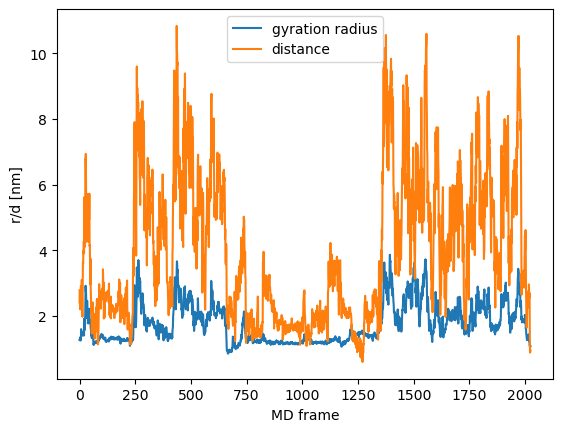

In [51]:
# Plot time series of radius of gyration (r) and distance (d)
plt.plot(data.time, data.r, label="gyration radius")
plt.plot(data.time, data.d, label="distance")

# x-y axis labels
plt.xlabel("MD frame")
plt.ylabel("r/d [nm]")
plt.legend()
plt.show()

Text(0, 0.5, 'distance [nm]')

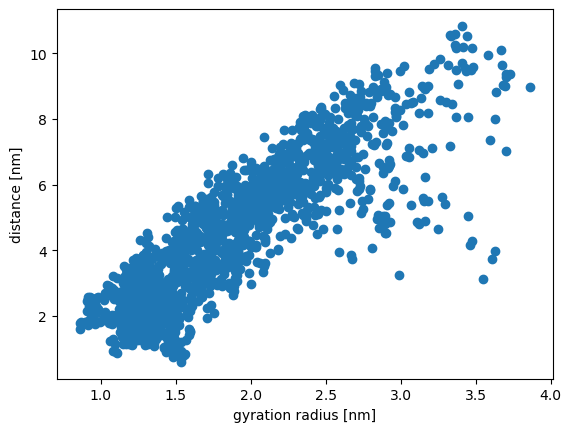

In [52]:
# plot gyration radius vs distance
plt.plot(data.r, data.d, "o")
plt.xlabel("gyration radius [nm]")
plt.ylabel("distance [nm]")

1. **What can you deduce about the dynamics of this region of 5-HT1B receptors?**  
Both distance and gyration radius indicate two distinct CVs. 
2. **Are the two CVs both providing useful information or they quite correlated?**  
Yes, from the distance vs time plot and gyration radius vs time, it is quite clear that they are correleated. 

## Exercise 2: Mastering advance selection tools

PLUMED provides some shortcuts to select atoms with specific properties to use this feature, we should specify the MOLINFO action along with a reference PDB file. This command is used to provide information on the molecules that are present in your system.

Let's try to use this functionality to calculate the backbone dihedral angle $\phi$ of residue 2 of the 5-HT1B receptor. This CV is defined by the action TORSION and a set of 4 atoms. For residue `i`, the dihedral angle $\phi$ is defined by these atoms: C(i-1), N(i), CA(i), C(i) as shown in the figure below:

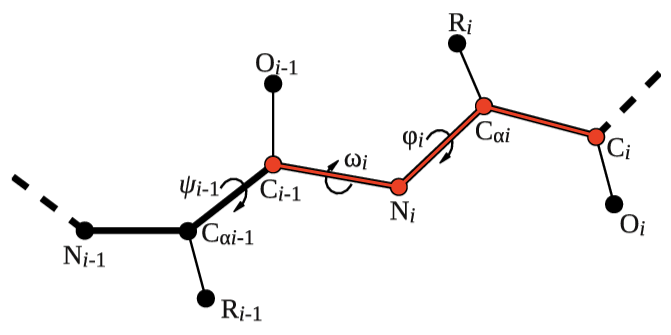

In [53]:
Image("figures/masterclass-21-1-dih-fig.png")

After consulting the manual and inspecting `5-HT1B.pdb`, let's define the dihedral angle `\phi` of residue 2 in two different ways:

1. specifying an explcit list of 4 atoms (`t1`).
2. using the MOLFINFO shorcut to select quadruplets for dihedral angles (`t2`);


In [54]:
# Exercise 2
# Extract index of atoms for phi of residue 2 (with awk)
# atoms: C(i-1),N(i),CA(i),C(i) 
!awk '{if(($6==1 && $3=="C") || ($6==2 && ($3=="N" || $3=="CA" || $3=="C")))printf "%d,",$2}END{printf "\n"}' data/5-HT1B.pdb

18,20,22,33,


In [72]:
%%bash
# Exercise 2
# Create a directory for this exercise
mkdir Exercise-2; cd Exercise-2
# Create PLUMED input file
cat > "plumed-A.dat" << EOF
MOLINFO STRUCTURE=../data/5-HT1B.pdb
# Define the dihedral phi of residue 2 as an explicit list of 4 atoms
t1: TORSION ATOMS=18,20,22,33

# Define the same dihedral using MOLINFO shortcuts
t2: TORSION ATOMS=@phi-2

# Print the two collective variables on COLVAR file every step
PRINT ARG=t1,t2 FILE=COLVAR-A STRIDE=1
EOF

# run the driver
plumed driver --plumed plumed-A.dat --mf_xtc ../data/5-HT1B.xtc

mkdir: Exercise-2: File exists



DRIVER: Found molfile format trajectory xtc with name ../data/5-HT1B.xtc
PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:28:06
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed
PLUMED: For installed feature, see /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 6684
PLUMED: File suffix: 
PLUMED: FILE: plumed-A.dat
PLUMED: Action MOLINFO
PLUMED:   with label @0
PLUMED:   pdb file named ../data/5-HT1B.pdb contains 2 chains 
PLUMED:   chain named A contains residues 1 to 10 and atoms 1 to 6658 
PLUMED:   chain named B contains residues 391 to 391 and atoms 6659

Let's visualize the the difference between `t1` and `t2`, if any. 

In [73]:
# import PLUMED COLVAR file into pandas dataset
data = plumed.read_as_pandas("Exercise-2/COLVAR-A")
print(data)

        time        t1        t2
0        0.0 -1.553501 -1.553501
1        1.0 -1.122330 -1.122330
2        2.0 -1.075468 -1.075468
3        3.0 -1.090167 -1.090167
4        4.0 -1.104332 -1.104332
...      ...       ...       ...
2020  2020.0 -1.388920 -1.388920
2021  2021.0 -2.080374 -2.080374
2022  2022.0 -1.889456 -1.889456
2023  2023.0 -2.078265 -2.078265
2024  2024.0 -0.972893 -0.972893

[2025 rows x 3 columns]


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++


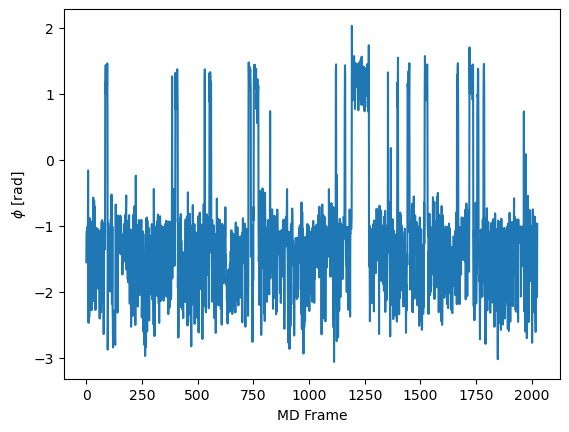

In [74]:
# plot the phi (t1) vs time
plt.plot(data.time, data.t1)
plt.xlabel("MD Frame")
plt.ylabel(r"$\phi$ [rad]")

plt.show()

Text(0, 0.5, 't1-t2 [rad]')

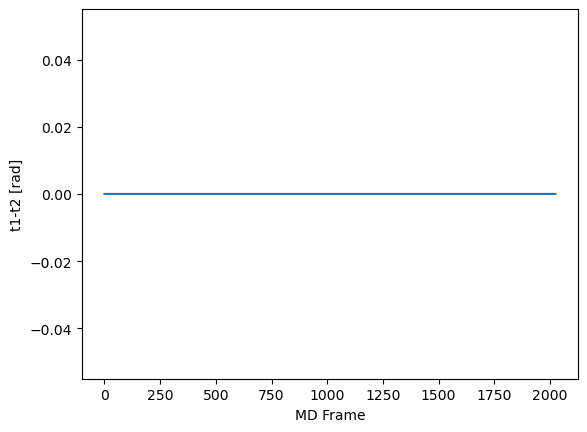

In [75]:
# Now let's plot the difference between t1 and t2
plt.plot(data.time, data.t1 - data.t2)
plt.xlabel("MD Frame")
plt.ylabel("t1-t2 [rad]")

We can see that the trajectories `t1` and `t2` are identical. 

As a second example of MOLINFO's capabilities, we will use the advance atom selction tools provided by [MDAnalysis](https://www.mdanalysis.org) and [MDTraj](https://mdtraj.org/1.9.4/index.html) libraries. Let's redo exercise 1 above but this tim use MOLINFO's shorcuts to select the CA atoms. We need to complete the following template PLUMED input file using the appropiate selection syntax for the corresponding library used. 

In [76]:
%%bash
# Exercise 2B
# go into directory for Exercise 2
cd Exercise-2

# create PLUMED input file
cat > "plumed-B.dat" << EOF
# Activate MOLINFO functionalities
MOLINFO STRUCTURE=../data/5-HT1B.pdb

# MDAnalysis syntax:
r1: GYRATION ATOMS={@mda:{resid 1:40 and name CA}}
d1: DISTANCE ATOMS={@mda:{resid 1 40 and name CA}}

# MDTraj syntax
r2: GYRATION ATOMS={@mdt:{resid 0 to 39 and name CA}}
d2: DISTANCE ATOMS={@mdt:{resid 0 39 and name CA}}

# Print the collective variables on COLVAR file every step
PRINT ARG=r1,d1,r2,d2 FILE=COLVAR-B STRIDE=1
EOF

# run the driver
plumed driver --plumed plumed-B.dat --mf_xtc ../data/5-HT1B.xtc


DRIVER: Found molfile format trajectory xtc with name ../data/5-HT1B.xtc
PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:28:06
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed
PLUMED: For installed feature, see /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 6684
PLUMED: File suffix: 
PLUMED: FILE: plumed-B.dat
PLUMED: Action MOLINFO
PLUMED:   with label @0
PLUMED:   pdb file named ../data/5-HT1B.pdb contains 2 chains 
PLUMED:   chain named A contains residues 1 to 10 and atoms 1 to 6658 
PLUMED:   chain named B contains residues 391 to 391 and atoms 6659

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++


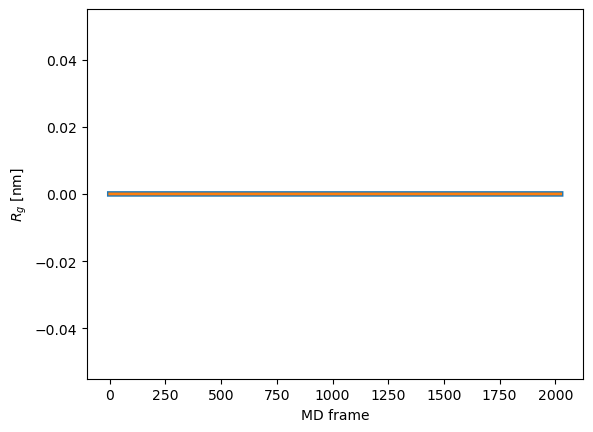

In [83]:
# import PLUMED COLVAR file into pandas dataset
data_1 = plumed.read_as_pandas("Exercise-1/COLVAR")
data_2 = plumed.read_as_pandas("Exercise-2/COLVAR-B")

# plot difference of gyration radius (Rg) from Exercise 1 and 2
plt.plot(data_2.time, data_2.r1 - data_1.r, lw = 4, label="Rg - MDAnalysis")
plt.plot(data_2.time, data_2.r2 - data_1.r, lw = 2, label="Rg - MDTraj")

# x-y axis labels
plt.xlabel("MD frame")
plt.ylabel(r"$R_{g}$ [nm]")
plt.show()

## Exercise 3: Using virtual atoms


Sometimes, when calculating a CV, we may not want to use the position of a number of atoms directly. Instead we may want to define a virtual atom whose position is generated based on the positions of a collection of other atoms. For example you might want to use the center of mass (COM) or the geometric center (CENTER) of a group of atoms. 

In this exercise, we will learn how to specify virtual atoms and later use them to define a CV. The objective is to calculate the distance between the geometric center of the serotonin ligand (indicated as residue `LIG` in `5-HT1B.pdb`) and the geometric centers of the two glycans located N24 and N32. Glycans are carbohydrate-based polymers that are sometimes linked to certain protein aminoacids. If we examine `5-HT1B.pdb`, we will find the two glycans defined after the end of the protien. These two glycans have different length:

* the glycan attached at position N24 (AA Asparagine with residue id 24) ranges from residue BGLC-1 to AFUC-9.
* the glycan attached at position N32 (AA Asparagine with residue id 32) ranges from residue BGLC-1 to AFUC-10.

Let's complete the PLUMED input file below. You can use the advance selection tools learned in exercise 2 to specify the atoms belonging to the ligand and to the two glycans:

In [95]:
%%bash
# Exercise 3
# go into directory for Exercise 3
mkdir Exercise-3; cd Exercise-3

# create PLUMED input file
cat > "plumed.dat" << EOF
# Geometric center of the ligand
lig: CENTER ATOMS=6659-6671
# Geometric center of the first glycan
g1: CENTER ATOMS=6212-6424
# Geometric center of the second glycan
g2: CENTER ATOMS=6425-6658


# Distance between ligand and first glycan
d1: DISTANCE ATOMS=lig,g1
# Distance between ligand and second glycan
d2: DISTANCE ATOMS=lig,g2

# Print the two distances on COLVAR file every step
PRINT ARG=d1,d2 FILE=COLVAR STRIDE=1
EOF

# run the driver 
plumed driver --plumed plumed.dat --mf_xtc ../data/5-HT1B.xtc

mkdir: Exercise-3: File exists



DRIVER: Found molfile format trajectory xtc with name ../data/5-HT1B.xtc
PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:28:06
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed
PLUMED: For installed feature, see /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 6684
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action CENTER
PLUMED:   with label lig
PLUMED:   serial associated to this virtual atom is 6685
PLUMED:   of atoms:
PLUMED:  6659 6660 6661 6662 6663 6664 6665 6666 6667 6668 6669 6670 6671
PLUMED:  using the geometric center
PLUMED:   broken

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++


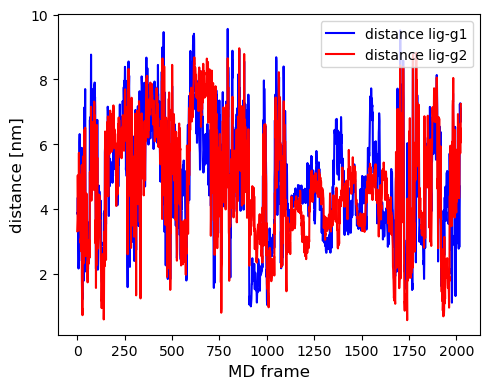

In [128]:
# import PLUMED COLVAR file into pandas dataset
data=plumed.read_as_pandas("Exercise-3/COLVAR")

plt.figure(figsize=(5, 4))

# plot time serie of distances to glycans
plt.plot(data.time,data.d1, c="blue",label="distance lig-g1")
plt.plot(data.time,data.d2,c="red", label="distance lig-g2")
# x-y axis labels
plt.xlabel("MD frame", fontsize=12)
plt.ylabel("distance [nm]", fontsize=12)
plt.legend()
# Ticks formatting
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Improve layout
plt.tight_layout()

# Improve layout
plt.tight_layout()

# minor ticks
ax.minorticks_on()

plt.show()

**Can you say if the ligan is overall staying closer to the first or second glycan?**  

In order to answer this question, we can calculate percentage of lig closer to g1 than g2. 

In [103]:
count = 0
for i in range(0, len(data.time)):
    if data.d1[i] <= data.d2[i]:
        count = count + 1.0

print(f"Percentage of frames with ligand closer to g1 than g2: {count/float(len(data.time))*100}%")

Percentage of frames with ligand closer to g1 than g2: 44.2962962962963%


## Exercise 4: Fixing PBCs discontinuities

`5-HT1B.xtc` is the raw trajectory generate by the GROMACS MD code. Therefore, it typically presents discontinuities due to PBCs. Many of the CVs used so far, such as CENTER or DISTANCE, take care of these discontinuties automaically. However, other CVs need a special command, called WHOLEMOLECULES, to fix PBCs discontinuiteis before the calculation of the CV. In this exercise, we will learn how this action. 

We have seen that the first 40 N-terminal residued of the `5-HT1B.xtc` receptor are quite flexible. In this exercise, we want to estimate the secondary structure content (alpha-helix and beta-sheet) of this fragement during the course of the MD simulations. How similar is this local strcutre to an ideal helix or beta sheet? In order to do so, we can use the following 3 CVs:

* ALPHARMSD to measure the alpha-helical content of a protein structue.
* PARABETARMSD to measure the parallel beta-sheet content.
* ANTIBETARMSD to measure the antiparallel beta-sheet content.

In [106]:
%%bash
# Exercise 4
# Create directory for this exercise
mkdir Exercise-4; cd Exercise-4
# Create PLUMED input file
cat > "plumed.dat" << EOF

# Info about the system
MOLINFO STRUCTURE=../data/5-HT1B.pdb

# make first 40 N-terminal residue whole
WHOLEMOLECULES ENTITY0={@mda:{protein and resid 1:40}}

# alpha helix content of residues 1-40
h: ALPHARMSD RESIDUES=1-40 TYPE=OPTIMAL

# parallel beta sheet content of residues 1-40
pb: PARABETARMSD RESIDUES=1-40 TYPE=OPTIMAL

# antiparallel beta sheet content of residues 1-40
ab: ANTIBETARMSD RESIDUES=1-40 TYPE=OPTIMAL

# now we can create a new CV that sums parallel and antiparallel beta sheet contents
b: COMBINE ARG=pb,ab PERIODIC=NO

# print the alpha helical content and the *total* beta sheet content on COLVAR
PRINT ARG=h,b FILE=COLVAR STRIDE=1
EOF

# run the driver
plumed driver --plumed plumed.dat --mf_xtc ../data/5-HT1B.xtc

mkdir: Exercise-4: File exists



DRIVER: Found molfile format trajectory xtc with name ../data/5-HT1B.xtc
PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:28:06
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed
PLUMED: For installed feature, see /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 6684
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action MOLINFO
PLUMED:   with label @0
PLUMED:   pdb file named ../data/5-HT1B.pdb contains 2 chains 
PLUMED:   chain named A contains residues 1 to 10 and atoms 1 to 6658 
PLUMED:   chain named B contains residues 391 to 391 and atoms 6659 t

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++


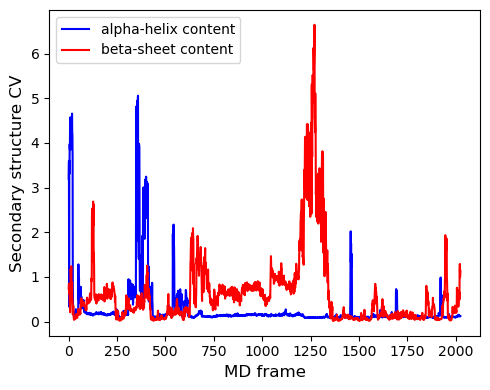

In [130]:
# import PLUMED COLVAR file into pandas dataset
data=plumed.read_as_pandas("Exercise-4/COLVAR")

plt.figure(figsize=(5, 4))
    
# plot time serie of distances to glycans
plt.plot(data.time,data.h, color="blue", label="alpha-helix content")
plt.plot(data.time,data.b, color="red", label="beta-sheet content")
# x-y axis labels
plt.xlabel("MD frame", fontsize=12)
plt.ylabel("Secondary structure CV", fontsize=12)
plt.legend()

# Ticks formatting
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)


# Improve layout
plt.tight_layout()

# minor ticks
ax.minorticks_on()

plt.show()

Time evolution of secondary-structure collective variables for residues 1-40 of the protein `5-HT1B.pdb`. The alpha-helical content (blue, ALPHARMSD) and total beta-sheet contetnt (red, sum of PARABETARMSD and ANTIBETARMSD) are show as function of MD frame. Higher values indicate greater stuctural similarity to the corresponding secondary motiff. 

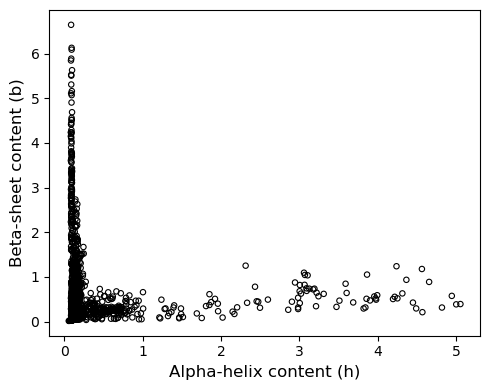

In [131]:
# Plot one against the other
plt.figure(figsize=(5, 4))

plt.scatter(data.h, 
            data.b,
            s = 15,
            edgecolors="black",
            facecolor="none", 
            lw=0.8)
plt.xlabel("Alpha-helix content (h)", fontsize=12)
plt.ylabel("Beta-sheet content (b)", fontsize=12)

# Ticks formatting
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Improve layout
plt.tight_layout()

# minor ticks
ax.minorticks_on()

plt.show()

**Can you say if the first 40 N-terminal residues toend to populate more alpha-helical or beta-sheet conformations?**

In [138]:
h = 0.0
b = 0.0

for i in range(0, len(data.time)):
    if data.h[i] >= 1.0:
        h += 1.0
    if data.b[i] >= 1.0:
        b += 1.0

print(f"Percentage of alpha helix: {h / float(len(data.time)) * 100.0: .1f}%")
print(f"Percentage of beta helix: {b / float(len(data.time)) * 100.0: .1f}%")


Percentage of alpha helix:  4.4%
Percentage of beta helix:  14.4%


## Exercise 5: Using RMSD to measure confirmation changes

As previously mentioned, the first 40 N-terminal residues of the `5-HT1B` receptor are quite flexible while the rest of the protein remains more stable during the course of the simulation. In this exercise, you will learn how to use RMSD to measure deviations from a reference structure. To use this CV, you need to keep in mind that you must specify in the PLUMED input a PDB file in which you mark the atoms that you want to use to:

* optimally align a conformation to the reference;
* calculate the displacement from the reference conformation after optimal alignment.

Keep in mind that these two sets of atom might be different! In fact, the objective of this exercise is to calculate:

* **RMSD-1: (Flexibility of N-terminal tail)** the RMSD of the backbone atom of the first 40 N-terminal residues after aligning the system on the backbone atoms of residues 41 to 390;
* **RMSD-2 (Stability of protein core):** the RMSD of the backbone atoms of residues 41 to 390 after aligning the system on the same set of atoms.

In order to calculate the RMSD between the reference structure and structure of interest, we need to mark atoms for alignment and displacement in the PDB files. 

PLUMED uses beta column to distinguish:

>`beta = 1 -> atoms used for alignment` <br>
>`beta = 0 -> ignored for alignment`

And occupancy column for displacement

>`occupancy = 1 -> atoms used for RMSD` <br>
>`occupancy = 0 -> ignored`



In [145]:
# First, wee need create two references PDBs to use with RMSD CVs
# RMSD-1:
# align -> residues 41-390 backbone
# measure -> residues 1-40 backbone
# RMSD-2:
# align -> residues 41-390 backbone
# measure -> residues 1-49 backbone

########################## RMSD - 1 ###################################

# Load the PDB structure into MDAnalysis
# This gives access to atoms, residues, selections, etc.
u = mda.Universe("data/5-HT1B.pdb")

# Get all atoms in the system
atoms = u.atoms


# Create arrays (same length as the number of atoms)
# These will store flags used by PLUMED
beta = np.zeros(len(atoms)) # will define ALIGNMENT atoms
occ = np.zeros(len(atoms)) # will define RMSD (measurement) atoms

#-------------------------------
# STEP 1: Define alignment atoms
#-------------------------------
# Select backbone atoms (N, CA, C, O) of residues 41-390
# These atoms will be used to ALIGN the structure to the reference
align_sel = u.select_atoms("protein and backbone and resid 41:390")

# set beta = 1 for these atoms
# In PLUMED: beta column = atoms used for alignment
beta[align_sel.indices] = 1.0


#-------------------------------
# STEP 2: Define measurement atoms
#-------------------------------
# Selection backbone atoms of residues 1-40
# These atoms are used to COMPUTE RMSD after alignment (STEP 1)
measure_sel = u.select_atoms("protein and backbone and resid 1:40")

# Set occupancy = 1 for these atoms
# In PLUMED: occupancy column = atoms used for RMSE calculation
occ[measure_sel.indices] = 1.0

#-------------------------------
# STEP 3: Store flags in PDB fields
#-------------------------------
# MDAnalysis maps:
# tempfactors -> PDB beta column
# occupancies -> PBB occupancy column

atoms.tempfactors = beta
atoms.occupancies = occ

#-------------------------------
# STEP 4:Write modified PDB
#-------------------------------
atoms.write("data/ref-1.pdb")

In [146]:
########################## RMSD - 2 ###################################
# Load the PDB structure into MDAnalysis
# This gives access to atoms, residues, selections, etc.
u = mda.Universe("data/5-HT1B.pdb")

# Get all atoms in the system
atoms = u.atoms


# Create arrays (same length as the number of atoms)
# These will store flags used by PLUMED
beta = np.zeros(len(atoms)) # will define ALIGNMENT atoms
occ = np.zeros(len(atoms)) # will define RMSD (measurement) atoms

#-------------------------------
# STEP 1: Define alignment atoms
#-------------------------------
# Select backbone atoms (N, CA, C, O) of residues 41-390
# These atoms will be used to ALIGN the structure to the reference
align_sel = u.select_atoms("protein and backbone and resid 41:390")

# set beta = 1 for these atoms
# In PLUMED: beta column = atoms used for alignment
beta[align_sel.indices] = 1.0


#-------------------------------
# STEP 2: Define measurement atoms
#-------------------------------
# Selection backbone atoms of residues 1-40
# These atoms are used to COMPUTE RMSD after alignment (STEP 1)
measure_sel = u.select_atoms("protein and backbone and resid 41:390")

# Set occupancy = 1 for these atoms
# In PLUMED: occupancy column = atoms used for RMSE calculation
occ[measure_sel.indices] = 1.0

#-------------------------------
# STEP 3: Store flags in PDB fields
#-------------------------------
# MDAnalysis maps:
# tempfactors -> PDB beta column
# occupancies -> PBB occupancy column

atoms.tempfactors = beta
atoms.occupancies = occ

#-------------------------------
# STEP 4:Write modified PDB
#-------------------------------
atoms.write("data/ref-2.pdb")

In [147]:
%%bash
# Exercise -5 
# Create directory for this exercise
mkdir Exercise-5; cd Exercise-5

# Create PLUMED input file
cat > "plumed.dat" << EOF

# Backbone RMSD of first 40 residues with alignment on backbone of residues 41-390
rmsd1: RMSD REFERENCE=../data/ref-1.pdb TYPE=OPTIMAL

# Backbone RMSE of residues 41-390 with alignment of same atoms
rmsd2: RMSD REFERENCE=../data/ref-2.pdb TYPE=OPTIMAL

# Print the two RMSD CVs on COLVAR file every step
PRINT ARG=rmsd1,rmsd2 FILE=COLVAR STRIDE=1
EOF

# run the driver
plumed driver --plumed plumed.dat --mf_xtc ../data/5-HT1B.xtc


DRIVER: Found molfile format trajectory xtc with name ../data/5-HT1B.xtc
PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:28:06
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed
PLUMED: For installed feature, see /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 6684
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action RMSD
PLUMED:   with label rmsd1
PLUMED:   reference from file ../data/ref-1.pdb
PLUMED:   which contains 6684 atoms
PLUMED:   with indices : 
PLUMED: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 
PLUMED: 26 27 28 2

**Can you say which part of the receptor is more flexible and deviates more from the starting conformation during the course of simulation?**

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++


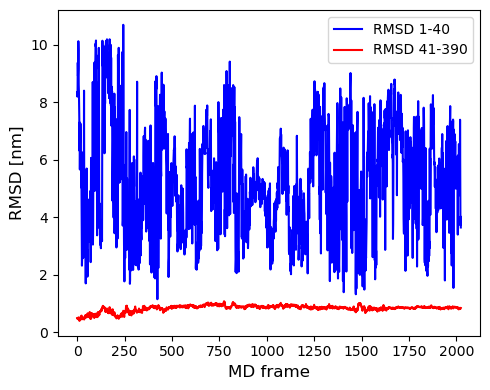

In [151]:
# import PLUMED COLVAR file into pandas dataset
data=plumed.read_as_pandas("Exercise-5/COLVAR")

plt.figure(figsize=(5, 4))
    
# plot time serie of distances to glycans
plt.plot(data.time,data.rmsd1, color="blue", label="RMSD 1-40")
plt.plot(data.time,data.rmsd2, color="red", label="RMSD 41-390")
# x-y axis labels
plt.xlabel("MD frame", fontsize=12)
plt.ylabel("RMSD [nm]", fontsize=12)
plt.legend()

# Ticks formatting
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Improve layout
plt.tight_layout()

# Improve layout
plt.tight_layout()

# minor ticks
ax.minorticks_on()

plt.show()

## Exercise 6: Aligning conformations to a template

In this execrsie, we will learn how to align a MD trajectory to a reference confirmation, after fixing possible discontinuities due to PBCs: periodic boundary fragementation, wrong periodic images, and global translation/roation of the system. The goal is to compute the vertical position of the serotonin ligand with respect to the lipid bilayer. In the simulations of membrane proteins, typically the initial conformation is oriented so that lipid bilayer is parallel to the xy plane (look for example at `5-HT1B.pdb`). Therefore, intially one could use for example the coordinate `z` of the geometric center of the ligand to measure how far it is from the membrane bilayer. However, during the simulaiton:

* the system can translate from its original position.
* the system can be broken by PBCs;

therefore on could not use an absolute position to keep track of the location of the ligand. To solve this problem, there are several PLUMED actions that can be used to make sure the system is not broken by PBCs, to re-align it to a reference conformation, and thus to use absolute positions safely. 

To complete this excercise, we need to make use of the PLUMED manual to prepare the input file on their own. In the following, some suggesion is given:

* first, make sure the entire protein is not broken by PBCs using WHOLEMOLECULES;
* then, make sure the ligand is not broken by PBCs and in the same cell as the protein, using the `WRAPAROUND` action and the `GROUPBY` option;
* to align the *stable* protein residues (as defined in exercise above, i.e. residues 41 to 390) to the template `5-HT1B.pdb`, you can use `FIT_TO_TEMPLATE`;
* at this point, you can safely define the position of the geometric center of the ligand using `POSITION CV` with the option `NOPBC`;
* the requeested CV is the `z` component of the POSITION CV.



In [154]:
%%bash
# Exercise 6
# Create directory for this exercise
mkdir Exercise-6; cd Exercise-6
# Create PLUMED input file
cat > "plumed.dat" << EOF
# Activate MOLINFO functionalities
MOLINFO STRUCTURE=../data/5-HT1B.pdb
# make the protein whole - glycans excluded
WHOLEMOLECULES ENTITY0={@mda:{protein}}
# define ligand group
lig: GROUP ATOMS={@mda:{resname LIG}}
# wrap ligand atoms around residues 1-40
# Residues 1-40 are used as the local anchor region. Probably this region
# is close to where the ligand binds.
WRAPAROUND ATOMS=lig AROUND={@mda:{protein and resid 1:40}} GROUPBY=26
# wrap glycan atoms around residues N24 and N32
WRAPAROUND ATOMS=6212-6424 AROUND={@mda:{protein and resid 24}} GROUPBY=213
WRAPAROUND ATOMS=6425-6658 AROUND={@mda:{protein and resid 32}} GROUPBY=234
# fit to template
# Aligns each frame to the reference structure ref-2.pdb
# Even after PBC reconstruction, the whole system can still:
# > translate
# > rotate
FIT_TO_TEMPLATE REFERENCE=../data/ref-2.pdb
# geometric center of the ligand (geometric center: the unweighted center of positions)
c-lig: CENTER ATOMS=lig
# Define Cartesian position of the point c-lig
p: POSITION ATOM=c-lig NOPBC
# dump conformations (all atoms: protein+glycans+ligand) to file to check
DUMPATOMS ATOMS=1-6684 FILE=5-HT1B_aligned.gro

# print component "z" of position CV (p.z) to COLVAR file every step
PRINT FILE=COLVAR STRIDE=1 ARG=p.z
EOF

# run the driver
plumed driver --plumed plumed.dat --mf_xtc ../data/5-HT1B.xtc

mkdir: Exercise-6: File exists



DRIVER: Found molfile format trajectory xtc with name ../data/5-HT1B.xtc
PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:28:06
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed
PLUMED: For installed feature, see /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 6684
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action MOLINFO
PLUMED:   with label @0
PLUMED:   pdb file named ../data/5-HT1B.pdb contains 2 chains 
PLUMED:   chain named A contains residues 1 to 10 and atoms 1 to 6658 
PLUMED:   chain named B contains residues 391 to 391 and atoms 6659 t

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++


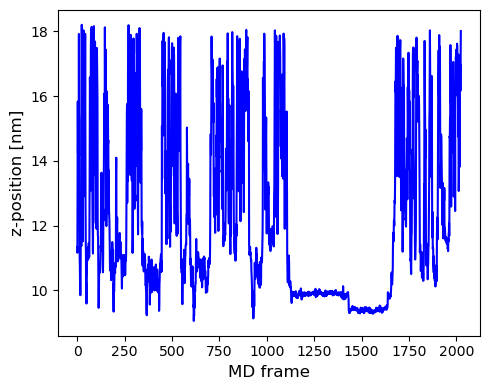

In [157]:
# import PLUMED COLVAR file into pandas dataset
data=plumed.read_as_pandas("Exercise-6/COLVAR")

plt.figure(figsize=(5, 4))

# plot time serie of z-position
plt.plot(data["time"],data["p.z"], color="blue")
# x-y axis labels
plt.xlabel("MD frame", fontsize=12)
plt.ylabel("z-position [nm]", fontsize=12)

# Ticks formatting
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Improve layout
plt.tight_layout()

# Improve layout
plt.tight_layout()

# minor ticks
ax.minorticks_on()

plt.show()

The z-position is a continous trajectory that spans the range from 9nm to 18nm.

## Exercise 7: Estimating binding propensity

In this last exercise, we want to determine the propensity of the serotonin ligand to bind the first 40 N-terminal flexible residues of the 5-HT1B receptor and if there are hot-spots where binding is more favorite. In order to answer to these questions, we will:
* compute the fraction of bound conformations over the total number of frames in the MD trajectory
* for each individual residue and glycan, compute the fraction of bound conformations per residue/glycan;
* dump all bound conformations to a `gro` file, after fixing PBCs as in exercise 6 above;

We should keep in mind the following instructions:
* A bound conformation is defined arbitarily: in which at least one pair of atoms of the ligand and of the protein/residue/glycan is closer than 0.4 nm;
* any pre-exisiting CV define in th PLUMED manual can be used;
* any CV defined directly by the user in the PLUMED input file via the CUSTOM action can be used. 

In [172]:
%%bash
# Exercise 7
# Create directory for this exercise
mkdir Exercise-7; cd Exercise-7
# create PLUMED input file
cat > "plumed.dat" << EOF
# Activate MOLINFO functionalities
MOLINFO STRUCTURE=../data/5-HT1B.pdb
# PBC fixing/alignment
WHOLEMOLECULES ENTITY0={@mda:{protein}}

#--------------------------------
# groups
#--------------------------------
# define ligand group
lig: GROUP ATOMS={@mda:{resname LIG}}
# first 40 N-terminal residues
nt40: GROUP ATOMS={@mda:{protein and resid 1:40}}
# glycan attached to N24
gly1: GROUP ATOMS=6212-6424
# glycan attached to N32
gly2: GROUP ATOMS=6425-6658
# alltargets
alltargets: GROUP ATOMS=nt40,gly1,gly2

# same wrapping strategy as exercise 6
WRAPAROUND ATOMS=lig AROUND=nt40 GROUPBY=26
WRAPAROUND ATOMS=gly1 AROUND={@mda:{protein and resid 24}} GROUPBY=213
WRAPAROUND ATOMS=gly2 AROUND={@mda:{protein and resid 32}} GROUPBY=234
# fit to template
FIT_TO_TEMPLATE REFERENCE=../data/ref-2.pdb
# global minimum distance
r0: DISTANCES GROUPA=lig GROUPB=alltargets MIN={BETA=50} NOPBC
# print global minimum distance
PRINT FILE=COLVAR_r0 STRIDE=1 ARG=r0.min
EOF
# add per-residue minimum distance and conditional dumps
for i in $(seq 1 40); do
cat >> "plumed.dat" << EOF
re${i}: GROUP ATOMS={@mda:{protein and resid ${i}}}
r${i}: DISTANCES GROUPA=lig GROUPB=re${i} MIN={BETA=50} NOPBC
PRINT FILE=COLVAR_r${i} STRIDE=1 ARG=r${i}.min
EOF
done
# add glycans
cat >> "plumed.dat" << EOF
g1: DISTANCES GROUPA=lig GROUPB=gly1 MIN={BETA=50} NOPBC
g2: DISTANCES GROUPA=lig GROUPB=gly2 MIN={BETA=50} NOPBC
PRINT FILE=COLVAR_g1 ARG=g1.min STRIDE=1
PRINT FILE=COLVAR_g2 ARG=g2.min STRIDE=1
EOF
# run the driver
plumed driver --plumed plumed.dat --mf_xtc ../data/5-HT1B.xtc

mkdir: Exercise-7: File exists



DRIVER: Found molfile format trajectory xtc with name ../data/5-HT1B.xtc
PLUMED: PLUMED is starting
PLUMED: Version: 2.9.2 (git: Unknown) compiled on Sep  4 2024 at 12:28:06
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed
PLUMED: For installed feature, see /Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 6684
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action MOLINFO
PLUMED:   with label @0
PLUMED:   pdb file named ../data/5-HT1B.pdb contains 2 chains 
PLUMED:   chain named A contains residues 1 to 10 and atoms 1 to 6658 
PLUMED:   chain named B contains residues 391 to 391 and atoms 6659 t

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libplumedKernel.dylib" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/dipteshgayen/anaconda3/envs/plumed-masterclass/lib/libpl

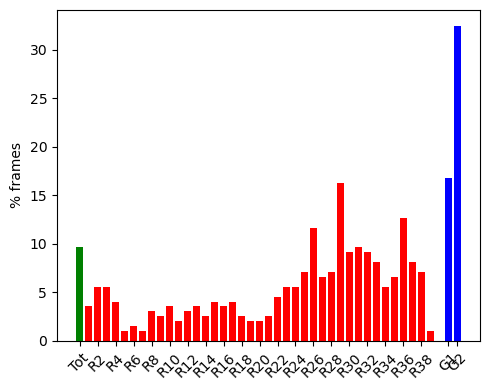

In [176]:
# now we analyze the results
# prepare list for bar plot
plt.figure(figsize=(5, 4))
bar=[]
# 1) bound conformations: total and per residue
for i in range(0,41):
    # import PLUMED COLVAR_r$i file into pandas dataset
    data=plumed.read_as_pandas("Exercise-7/COLVAR_r"+str(i))
    count=0.
    for d in data["r"+str(i)+".min"]:
        # count bound conformations
        if(d<0.4): count+=1.0
    bar.append(count)
# 2) bound conformations per glycan
for i in range(1,3):
    # import PLUMED COLVAR_g$i file into pandas dataset
    data=plumed.read_as_pandas("Exercise-7/COLVAR_g"+str(i))
    count=0.
    for d in data["g"+str(i)+".min"]:
        # count bound conformations
        if(d<0.4): count+=1.0
    bar.append(count)
# normalization by total number of bound conformations
for i in range(1,43):
    bar[i] = bar[i] / bar[0] * 100.0
# normalization by total number of frames in MD trajectory
bar[0] = bar[0] / float(len(data["time"])) * 100.0
# create a bar plot
ind=range(0,43)
# total fraction of bound conformations
plt.bar(ind[0],    bar[0],    0.75, color="g")
# fraction of bound conformations per residue
plt.bar(ind[1:-2], bar[1:-2], 0.75, color="r")
# fraction of bound conformations per glycan
plt.bar(ind[-2:],  bar[-2:],  0.75, color="b")
# set ticks and labels
lab = ["Tot"]; ticks=[0]
for i in range(2,40,2):
    lab.append("R"+str(i))
    ticks.append(i)
lab += ["G1","G2"]; ticks += [41,42]
plt.xticks(ticks, lab, rotation=45)
plt.ylabel("% frames")

# Ticks formatting
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Improve layout
plt.tight_layout()

# Improve layout
plt.tight_layout()

# minor ticks
ax.minorticks_on()


plt.show()